In [146]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

In [147]:
housing = fetch_california_housing()

df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

df['median_house_value'] = housing.target * 100000

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [148]:
print(df.shape)

df.info()

df.head()

(20640, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MedInc              20640 non-null  float64
 1   HouseAge            20640 non-null  float64
 2   AveRooms            20640 non-null  float64
 3   AveBedrms           20640 non-null  float64
 4   Population          20640 non-null  float64
 5   AveOccup            20640 non-null  float64
 6   Latitude            20640 non-null  float64
 7   Longitude           20640 non-null  float64
 8   median_house_value  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,median_house_value
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,452600.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,358500.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,352100.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,341300.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,342200.0


In [149]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
MedInc                0
HouseAge              0
AveRooms              0
AveBedrms             0
Population            0
AveOccup              0
Latitude              0
Longitude             0
median_house_value    0
dtype: int64


In [150]:
# Target Variable
y = df['median_house_value']

# Feature Variable
X = df[['MedInc']]

In [151]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [152]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [153]:
y_pred = model.predict(X_test)

In [154]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, y_pred)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE :", rmse)
print("MAE :", mae)
print("R2 Score :", r2)

MSE : 7091157771.765549
RMSE : 84209.01241414454
MAE : 62990.86530093761
R2 Score : 0.45885918903846645


In [155]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,47700.0,114958.916770
1,45800.0,150606.882140
2,500001.0,190393.718444
3,218600.0,285059.383451
4,278000.0,200663.318161
5,158700.0,242165.248906
6,198200.0,257647.226102
7,157500.0,199229.180512
8,340000.0,245893.168117
9,446600.0,384677.436071


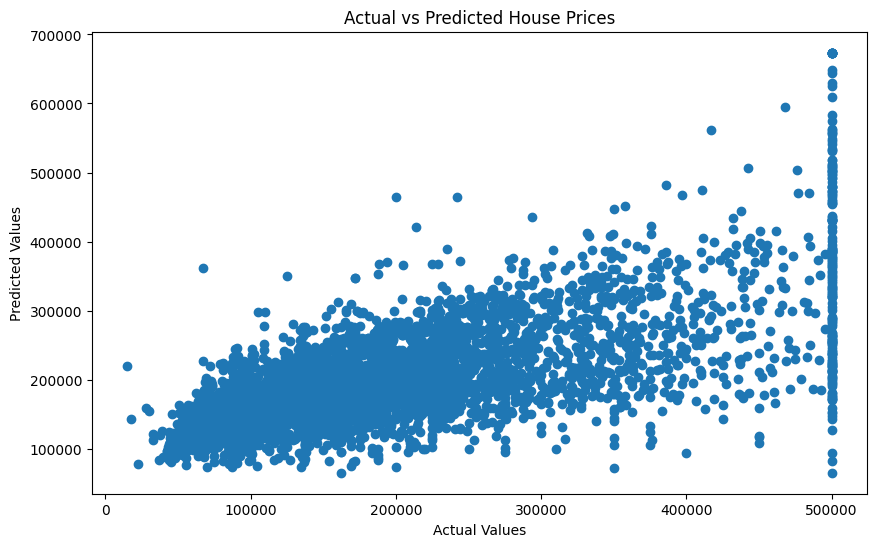

In [156]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [157]:
X_A = df[['MedInc']]

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A,
    y,
    test_size=0.2,
    random_state=42
)

model_A = LinearRegression()

model_A.fit(X_train_A, y_train_A)

pred_A = model_A.predict(X_test_A)

In [158]:
mse_A = mean_squared_error(y_test_A, pred_A)
rmse_A = np.sqrt(mse_A)
mae_A = mean_absolute_error(y_test_A, pred_A)
r2_A = r2_score(y_test_A, pred_A)

In [159]:
X_B = df[
    [
        'MedInc',
        'HouseAge',
        'AveRooms',
        'Population'
    ]
]


X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(
    X_B,
    y,
    test_size=0.2,
    random_state=42
)


model_B = LinearRegression()

model_B.fit(X_train_B, y_train_B)

pred_B = model_B.predict(X_test_B)

In [160]:
mse_B = mean_squared_error(y_test_B, pred_B)

rmse_B = np.sqrt(mse_B)

mae_B = mean_absolute_error(y_test_B, pred_B)

r2_B = r2_score(y_test_B, pred_B)

In [161]:
comparison_table = pd.DataFrame({
    'Metric':['MSE','RMSE','MAE','R2'],
    'Model A':[mse_A,rmse_A,mae_A,r2_A],
    'Model B':[mse_B,rmse_B,mae_B,r2_B]
})

comparison_table

,Metric,Model A,Model B
0,MSE,7.091158e+09,6.577996e+09
1,RMSE,8.420901e+04,8.110484e+04
2,MAE,6.299087e+04,6.024696e+04
3,R2,4.588592e-01,4.980196e-01


In [162]:
print("""
Model B performed better because it uses multiple
features and achieved better test performance.
Its R² score is higher and errors are lower.
""")


Model B performed better because it uses multiple
features and achieved better test performance.
Its R² score is higher and errors are lower.



In [163]:
def evaluate_split(test_size):

    X = df[['MedInc', 'HouseAge', 'AveRooms', 'Population']]

    y = df['median_house_value']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    return [
        test_size,
        mean_squared_error(y_train, train_pred),
        mean_squared_error(y_test, test_pred),
        np.sqrt(mean_squared_error(y_train, train_pred)),
        np.sqrt(mean_squared_error(y_test, test_pred)),
        mean_absolute_error(y_train, train_pred),
        mean_absolute_error(y_test, test_pred),
        r2_score(y_train, train_pred),
        r2_score(y_test, test_pred)
    ]

In [164]:
results = []

results.append(evaluate_split(0.20))
results.append(evaluate_split(0.30))
results.append(evaluate_split(0.40))

In [165]:
print(df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'median_house_value'],
      dtype='object')


In [166]:
split_results = pd.DataFrame(
    results,
    columns=[
        'Test Size',
        'Train MSE',
        'Test MSE',
        'Train RMSE',
        'Test RMSE',
        'Train MAE',
        'Test MAE',
        'Train R2',
        'Test R2'
    ]
)

split_results

,Test Size,Train MSE,Test MSE,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2
0,0.2,6.467542e+09,6.577996e+09,80421.026839,81104.843743,59817.695663,60246.959353,0.516184,0.498020
1,0.3,6.532172e+09,6.390322e+09,80821.850920,79939.492113,60079.290803,59608.031341,0.512414,0.513133
2,0.4,6.452825e+09,6.545196e+09,80329.477847,80902.382938,59628.318264,60222.184090,0.513623,0.511080


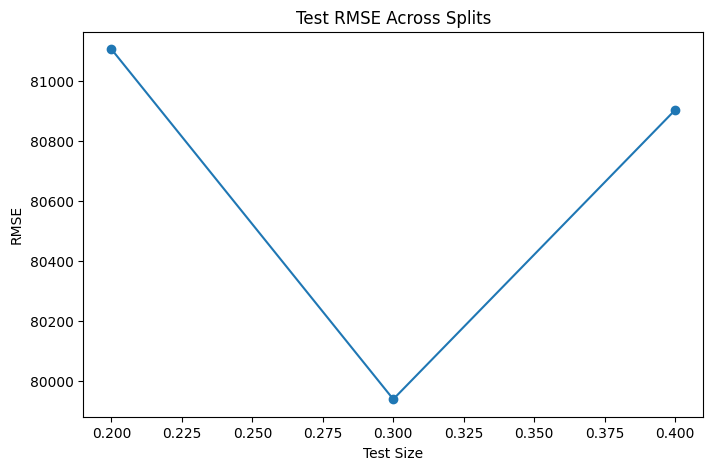

In [167]:
plt.figure(figsize=(8,5))

plt.plot(
    split_results['Test Size'],
    split_results['Test RMSE'],
    marker='o'
)

plt.title("Test RMSE Across Splits")

plt.xlabel("Test Size")

plt.ylabel("RMSE")

plt.show()

In [168]:
print("""
The split with highest Test R² and lowest Test RMSE
is considered the most reliable.
Usually 80/20 provides balanced performance.
""")


The split with highest Test R² and lowest Test RMSE
is considered the most reliable.
Usually 80/20 provides balanced performance.



In [169]:
best_model = model_B

best_pred = pred_B

In [170]:
manual_mse = np.mean((y_test_B - best_pred)**2)

manual_rmse = np.sqrt(manual_mse)

manual_mae = np.mean(np.abs(y_test_B - best_pred))

manual_r2 = 1 - (
    np.sum((y_test_B-best_pred)**2)
    /
    np.sum((y_test_B-y_test_B.mean())**2)
)

print("Manual MSE :", manual_mse)
print("Manual RMSE :", manual_rmse)
print("Manual MAE :", manual_mae)
print("Manual R2 :", manual_r2)

Manual MSE : 6577995678.634071
Manual RMSE : 81104.84374335525
Manual MAE : 60246.95935335576
Manual R2 : 0.4980196421223846


In [171]:
median_ae = median_absolute_error(
    y_test_B,
    best_pred
)

print("Median Absolute Error:", median_ae)

Median Absolute Error: 48132.14775829691


In [172]:
metrics_table = pd.DataFrame({
    'Metric':[
        'MSE',
        'RMSE',
        'MAE',
        'R2',
        'Median AE'
    ],
    'Value':[
        manual_mse,
        manual_rmse,
        manual_mae,
        manual_r2,
        median_ae
    ]
})

metrics_table

,Metric,Value
0,MSE,6.577996e+09
1,RMSE,8.110484e+04
2,MAE,6.024696e+04
3,R2,4.980196e-01
4,Median AE,4.813215e+04


In [173]:
modified_pred = best_pred.copy()

modified_pred[:3] += 500000

In [174]:
original_mse = mean_squared_error(
    y_test_B,
    best_pred
)

new_mse = mean_squared_error(
    y_test_B,
    modified_pred
)

original_rmse = np.sqrt(original_mse)

new_rmse = np.sqrt(new_mse)

original_mae = mean_absolute_error(
    y_test_B,
    best_pred
)

new_mae = mean_absolute_error(
    y_test_B,
    modified_pred
)

print("Original MSE:", original_mse)
print("New MSE:", new_mse)

print("Original RMSE:", original_rmse)
print("New RMSE:", new_rmse)

print("Original MAE:", original_mae)
print("New MAE:", new_mae)

Original MSE: 6577995678.634071
New MSE: 6734910345.807393
Original RMSE: 81104.84374335525
New RMSE: 82066.49953426424
Original MAE: 60246.95935335576
New MAE: 60481.41003280488


In [175]:
print("""
MSE reacts most strongly to large prediction errors
because errors are squared.

RMSE also increases significantly because it is
derived from MSE.

MAE increases linearly and is less sensitive
to extreme outliers.
""")


MSE reacts most strongly to large prediction errors
because errors are squared.

RMSE also increases significantly because it is
derived from MSE.

MAE increases linearly and is less sensitive
to extreme outliers.

